In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

ruta = "../out/espectros_CR39.out"
ruta_airegel = "../out/espectro_airegel.out"

espectros = {}
numero_actual = None
leyendo = False

with open(ruta, "r") as f:
    for linea in f:

        if "no. =" in linea and "reg =" in linea:
            try:
                numero_actual = int(linea.split("no. =")[1].split()[0])
            except:
                pass

        if "#  e-lower" in linea and "e-upper" in linea:
            leyendo = True
            energia = []
            flujo = []
            continue

        if leyendo and "#   sum over" in linea:
            espectros[numero_actual] = (
                np.array(energia),
                np.array(flujo)
            )
            leyendo = False
            continue

        if leyendo:
            datos = linea.split()

            if len(datos) >= 4:
                try:
                    e_lower = float(datos[0])
                    e_upper = float(datos[1])
                    valor = float(datos[2])

                    energia.append((e_lower + e_upper) / 2)
                    flujo.append(valor)

                except ValueError:
                    pass


energia_airegel = []
flujo_airegel = []
leyendo = False

with open(ruta_airegel, "r") as f:
    for linea in f:

        if "#  e-lower" in linea and "e-upper" in linea:
            leyendo = True
            continue

        if leyendo and "#   sum over" in linea:
            break

        if leyendo:
            datos = linea.split()

            if len(datos) >= 4:
                try:
                    e_lower = float(datos[0])
                    e_upper = float(datos[1])
                    valor = float(datos[2])

                    energia_airegel.append((e_lower + e_upper) / 2)
                    flujo_airegel.append(valor)

                except ValueError:
                    pass

energia_airegel = np.array(energia_airegel)
flujo_airegel = np.array(flujo_airegel)

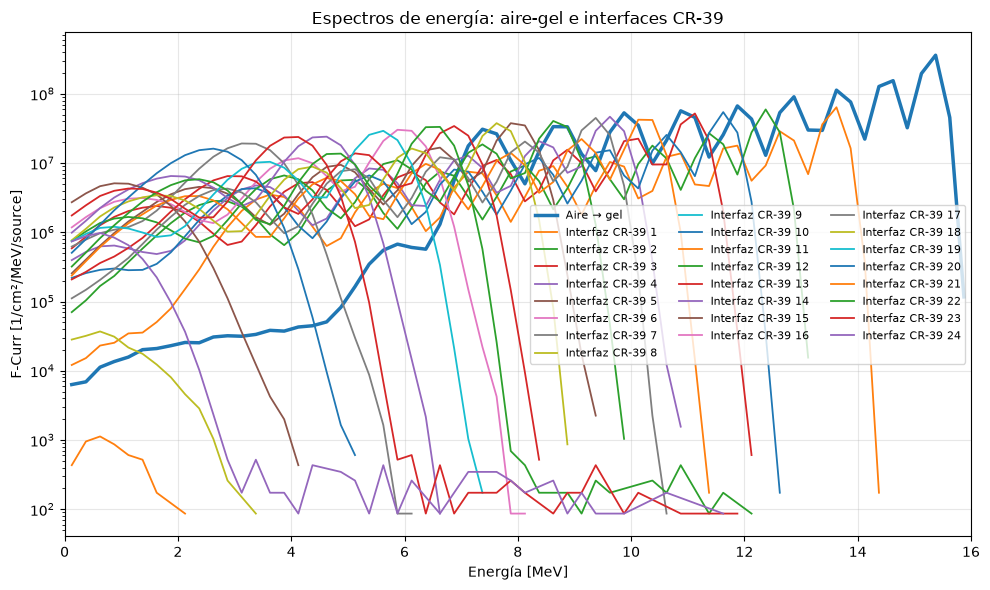

In [2]:
plt.figure(figsize=(10, 6))

mask = flujo_airegel > 0

plt.plot(
    energia_airegel[mask],
    flujo_airegel[mask],
    linewidth=2.5,
    label="Aire → gel"
)

for n, (energia, flujo) in espectros.items():

    mask = flujo > 0

    plt.plot(
        energia[mask],
        flujo[mask],
        linewidth=1.3,
        label=f"Interfaz CR-39 {n}"
    )

plt.xlabel("Energía [MeV]")
plt.ylabel("F-Curr [1/cm²/MeV/source]")
plt.title("Espectros de energía: aire-gel e interfaces CR-39")

plt.yscale("log")
plt.xlim(0, 16)

plt.grid(alpha=0.3)
plt.legend(ncol=3, fontsize=8)

plt.tight_layout()
plt.show()

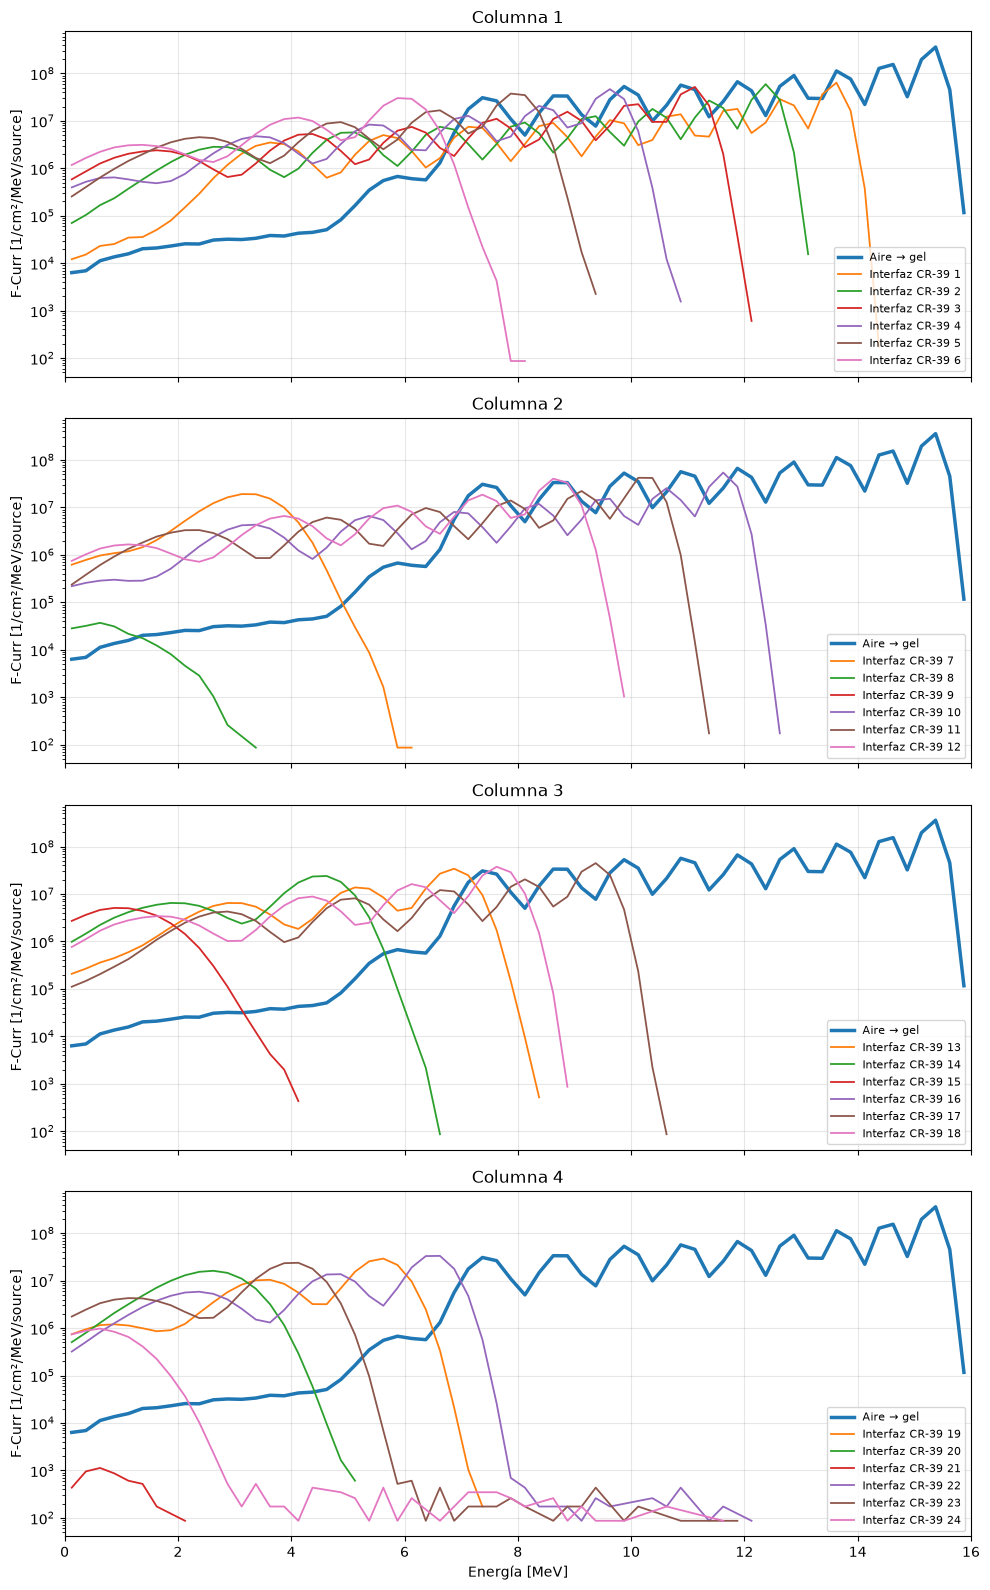

In [3]:
fig, axs = plt.subplots(4, 1, figsize=(10, 16), sharex=True)

for i, ax in enumerate(axs):

    mask_ag = flujo_airegel > 0

    ax.plot(
        energia_airegel[mask_ag],
        flujo_airegel[mask_ag],
        linewidth=2.5,
        label="Aire → gel"
    )

    for n, (energia, flujo) in espectros.items():

        columna = (n - 1) // 6

        if columna == i:

            mask = flujo > 0

            ax.plot(
                energia[mask],
                flujo[mask],
                linewidth=1.3,
                label=f"Interfaz CR-39 {n}"
            )

    ax.set_ylabel("F-Curr [1/cm²/MeV/source]")
    ax.set_yscale("log")
    ax.set_xlim(0, 16)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

    ax.set_title(f"Columna {i + 1}")

axs[-1].set_xlabel("Energía [MeV]")

plt.tight_layout()
plt.show()

El zigzagueo observado en el espectro de energía probablemente se debe a la discretización del ridge filter en espesores escalonados, ya que cada espesor produce una pérdida de energía diferente y genera grupos de protones con energías preferenciales, dando lugar a una estructura periódica en el espectro en lugar de una distribución completamente continua.